In [1]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('glass.xlsx', sheet_name='glass')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
df.shape

(214, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [7]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [8]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

there are no null values in this dataset.

In [9]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


the glass dataset consists of multiple numerical features representing chemical properties of a glass. the exploratory analysis showed no missing values. all input features are continuos and vary across different scales. the target variable represents multiple glass types, making this  a multiclass classification problem .

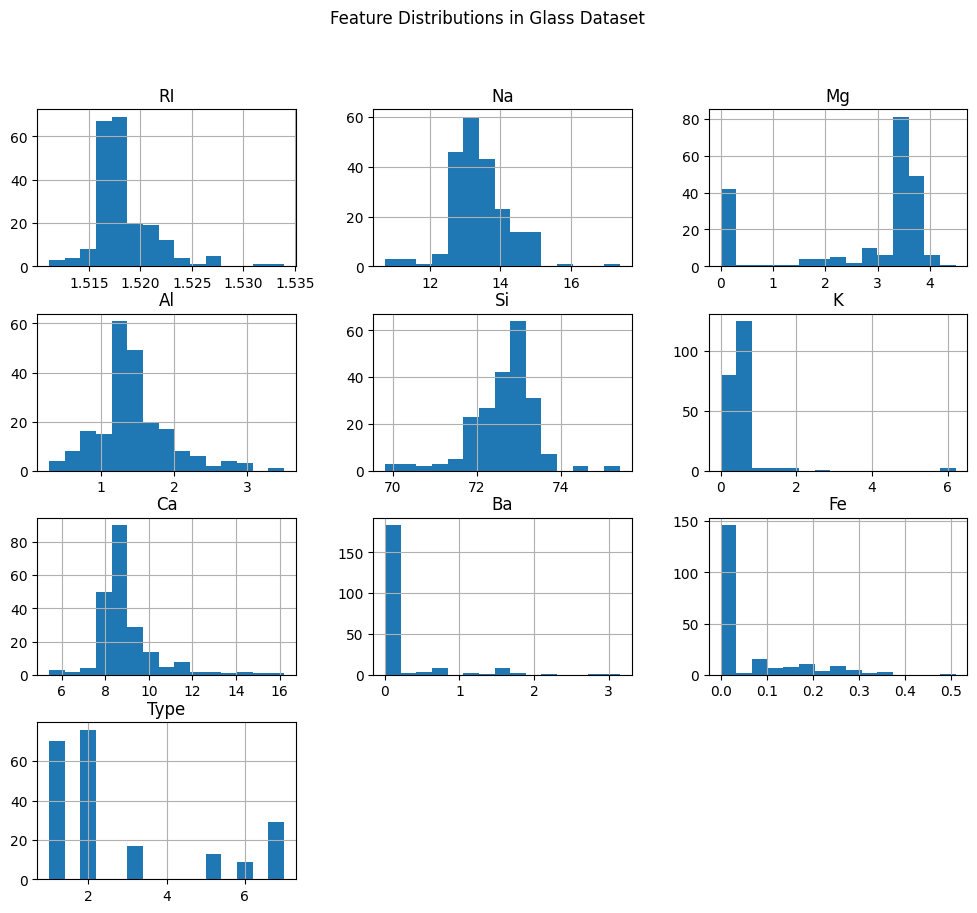

In [10]:
df.hist(figsize=(12,10), bins=15)
plt.suptitle("Feature Distributions in Glass Dataset")
plt.show()

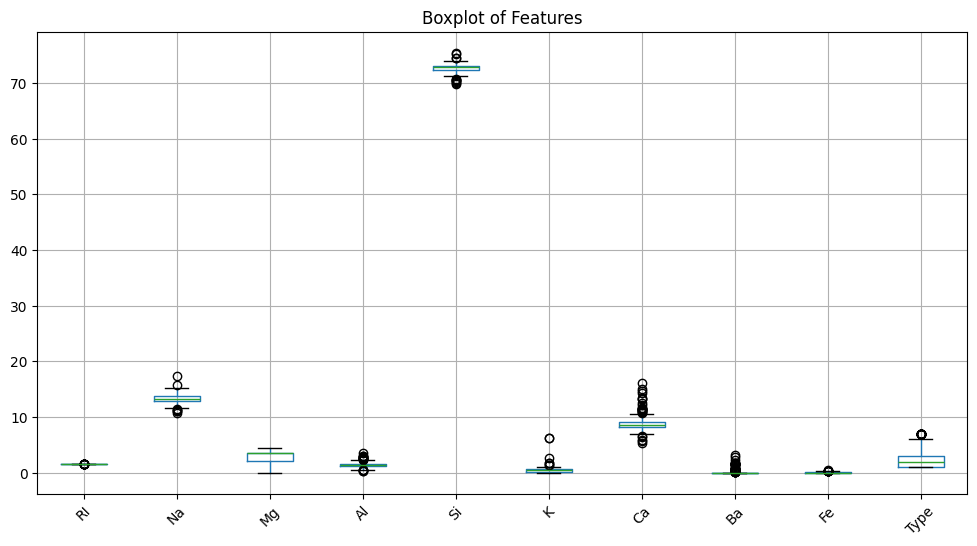

In [11]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

you can see that several features contains outliers in the dataset. we will not remove outliers here since random forest is capable of handling outliers. these outliers may represent valid glass composistions.

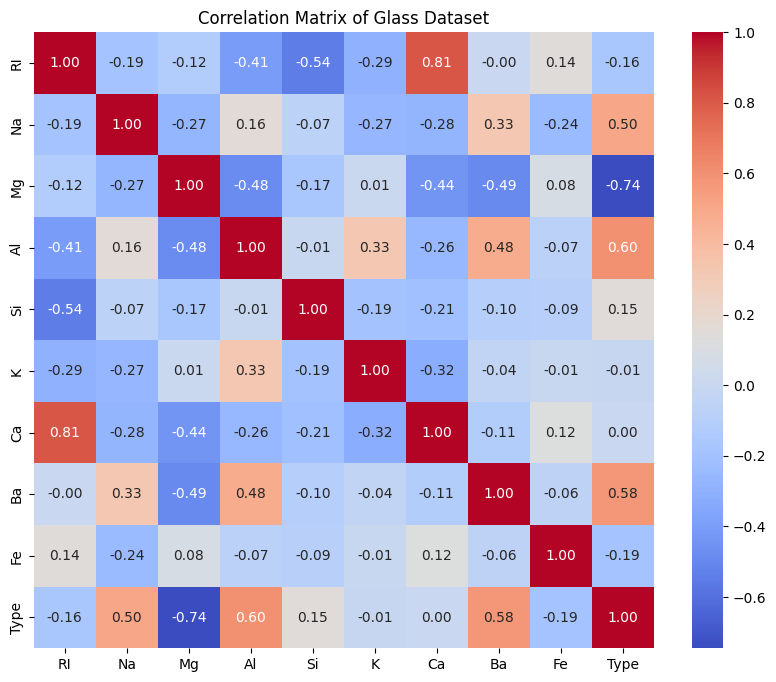

In [12]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Glass Dataset")
plt.show()


you can see that some featuers are moderatly correlated in the dataset. such as Refractive index and calcium , etc. random forest can handle correlated features well. since there is no extreme multicollinearity random forest is suitable.

Histogram revealed that most chemical composition features exhibit skewed distributions and vary significantly in scale. box plot highlighted the presense of outliers across several attributes. however these were retained as random forest models are robust to extreme values.

# preprocessing and Feature scaling

In [13]:
df.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

In [14]:
X = df.drop(columns=['Type'])
y = df['Type']

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_scaled

array([[ 0.87286765,  0.28495326,  1.25463857, ..., -0.14576634,
        -0.35287683, -0.5864509 ],
       [-0.24933347,  0.59181718,  0.63616803, ..., -0.79373376,
        -0.35287683, -0.5864509 ],
       [-0.72131806,  0.14993314,  0.60142249, ..., -0.82894938,
        -0.35287683, -0.5864509 ],
       ...,
       [ 0.75404635,  1.16872135, -1.86551055, ..., -0.36410319,
         2.95320036, -0.5864509 ],
       [-0.61239854,  1.19327046, -1.86551055, ..., -0.33593069,
         2.81208731, -0.5864509 ],
       [-0.41436305,  1.00915211, -1.86551055, ..., -0.23732695,
         3.01367739, -0.5864509 ]])

In [17]:
y.value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

WE will address the class imbalance issue by assigning more weights to the minority class during the model training phase.

# Random forest classifier

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                  class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [21]:
y_pred =rf_model.predict(X_test)

In [22]:
y_pred

array([7, 5, 2, 5, 1, 2, 2, 5, 1, 1, 3, 1, 7, 6, 1, 7, 7, 1, 1, 5, 2, 1,
       7, 2, 1, 1, 2, 6, 2, 1, 2, 1, 1, 2, 2, 2, 1, 1, 2, 3, 1, 2, 6],
      dtype=int64)

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)


Accuracy: 0.7441860465116279

Classification Report:
               precision    recall  f1-score   support

           1       0.69      0.79      0.73        14
           2       0.77      0.67      0.71        15
           3       0.50      0.33      0.40         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.73      0.77      0.74        43
weighted avg       0.75      0.74      0.74        43



array([[11,  2,  1,  0,  0,  0],
       [ 3, 10,  0,  1,  1,  0],
       [ 2,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  3,  0,  0],
       [ 0,  0,  0,  0,  2,  0],
       [ 0,  1,  0,  0,  0,  5]], dtype=int64)

A Random Forest classifier was trained using an ensemble of decision trees to improve predictive performance and robustness. The dataset was divided into training and testing subsets using an 80–20 split while preserving class distribution. To address class imbalance, class weights were applied during training. The model’s performance was evaluated using accuracy, precision, recall, and F1-score, providing a comprehensive assessment of classification effectiveness across all glass types.

the model correctly identified that 3 out of 4 glass samples. the support for calss 1 and 2 are good around 14 and 15 each. but the class 3 is problematic with 33 recall maybe dueto extremely small sample size model is strugling to learn stable pattern. the rest of the classes have a higher recall.

macro avg and avg have  both similar f1 around 0.74 it indicates that our model is not overly biased and class weights helped the model.

# bagging and boosting methods

In [24]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_model = BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                n_estimators=100,
                random_state=42)
bagging_model.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, random_state=42)

In [26]:
y_pred_bag = bagging_model.predict(X_test)

In [27]:
y_pred_bag

array([7, 5, 2, 5, 1, 2, 2, 5, 1, 1, 3, 1, 7, 6, 1, 7, 7, 1, 1, 2, 1, 1,
       7, 2, 1, 3, 2, 6, 2, 2, 7, 1, 1, 2, 2, 2, 1, 1, 2, 3, 7, 2, 6],
      dtype=int64)

In [28]:
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("\nBagging Classification Report:\n", classification_report(y_test, y_pred_bag))


Bagging Accuracy: 0.7906976744186046

Bagging Classification Report:
               precision    recall  f1-score   support

           1       0.79      0.79      0.79        14
           2       0.85      0.73      0.79        15
           3       0.67      0.67      0.67         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                           0.79        43
   macro avg       0.75      0.81      0.77        43
weighted avg       0.79      0.79      0.79        43



you can see here that the accuracy increased from random forest(74) to bagging(79). higher accuracy is meaningfull here since the overall class wise performance also improved. you can see that minority classes are now interpretable more clearly from the macro and weighted average, performance is not dominated by majority classes, bagging handles imbalance better that baseline random forest.

In [29]:
from sklearn.ensemble import AdaBoostClassifier

boosting_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting_model.fit(X_train, y_train)

y_pred_boost = boosting_model.predict(X_test)


C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [30]:
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))
print("\nBoosting Classification Report:\n", classification_report(y_test, y_pred_boost))


Boosting Accuracy: 0.5348837209302325

Boosting Classification Report:
               precision    recall  f1-score   support

           1       0.54      0.93      0.68        14
           2       0.42      0.33      0.37        15
           3       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.50      1.00      0.67         2
           7       1.00      0.50      0.67         6

    accuracy                           0.53        43
   macro avg       0.41      0.46      0.40        43
weighted avg       0.48      0.53      0.48        43



C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

the performance worsened in this , it dropped to directly 53.5 %. it indicates that the boosting model did not suit this dataset very well.

Although Boosting showed high recall for certain classes, it failed to generalize across minority glass types, completely missing some rare classes. This behavior highlights Boosting’s sensitivity to noise and class imbalance in small datasets. Consequently, Boosting was less suitable for this dataset compared to Bagging-based ensemble methods.

# interview questions

1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging:

Bagging is an ensemble learning technique in which multiple models are trained independently on different  random subsets of training daa created using bootstrapping(sampling with replacement). the final prediction is obtained by aggregating the predictions of all models, or majority voting for classification. the key characteristics include models are trained in parallel, it reduces variance, it is less sensitive to noise, it works well with unstable models such as decision rees.

Boosting:

Boosting is an ensemble learning technique where models are trained sequentially, and each new model focuses more on the samples that were misclassified by previous models. The final prediction is obtained by combining the weighted predictions of all models. the key characteristics include that the models are trained sequentially, it reduces bias , it gives more importance to  difficuklt or missclassified   samples. it is also sensitive to noise and outliers.

2. Explain how to handle imbalance in the data.

imbalanced data occurs when some classes have significantly fewer samples than others, which can cause machine leanring models to biased towards majority classes.

techniques:

1.resampling techniques:
    oversampling: increases the samples of minority classes.
    undersampling: reduces the samples of majority classes.
    
2.class weighting
    assigns higher weights to minority classes during model training, which forces the model to pay more attention to underpresented classes.
    
3. algorithmic approach
     we use models that can naturally handle imbalance, use ensemble methods to improve minority class learning.
     
